# Clinical Readmission Analytics

## Statistical Analysis

This notebook evaluates whether observed differences between patient groups are statistically significant.

In [2]:
import pandas as pd
import numpy as np

from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

# project setup
# Project Setup

import sys
import os

sys.path.append(
    os.path.abspath("..")
)

In [3]:
df = pd.read_csv(
    "../data/cleaned_diabetes_readmission.csv"
)

df.shape

(101766, 45)

## Simplify Readmission

In [4]:
# create

df["readmitted_binary"] = np.where(
    df["readmitted"] == "NO",
    "Not Readmitted",
    "Readmitted"
)

In [5]:
df["readmitted_binary"].value_counts()

readmitted_binary
Not Readmitted    54864
Readmitted        46902
Name: count, dtype: int64

## First Satatistical test:

Do readmitted patients stay longer in hospital?

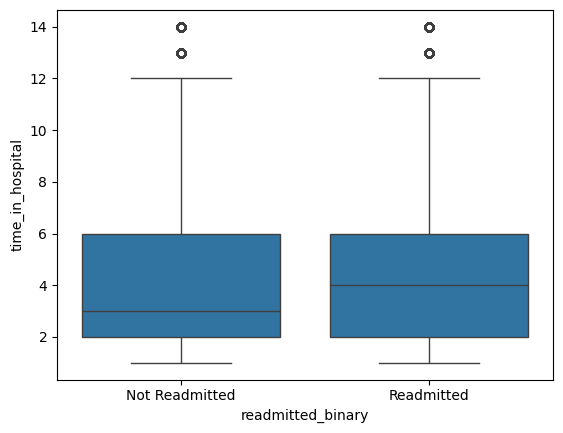

In [6]:
# Visualize

sns.boxplot(
    data=df,
    x="readmitted_binary",
    y="time_in_hospital"
)

plt.show()

In [7]:
# Split groups

readmitted = df[
    df["readmitted_binary"] == "Readmitted"
]["time_in_hospital"]

not_readmitted = df[
    df["readmitted_binary"] == "Not Readmitted"
]["time_in_hospital"]

### Hypothesis

H₀:
There is no difference in hospital stay duration.

H₁:
Hospital stay duration differs between groups.

# Mann-Whitney U Test

Because:

`time_in_hospital` is not normally distributed. 

In [8]:
stat, p = stats.mannwhitneyu(
    readmitted,
    not_readmitted
)

print("Statistic:", stat)
print("P-value:", p)

Statistic: 1376770775.5
P-value: 2.116668190051554e-84


### Interpretation

If p < 0.05:

Reject the null hypothesis.

The difference in hospital stay duration is statistically significant.

# Second Test

## Number of Medications

Do readmitted patients recieve more medications?

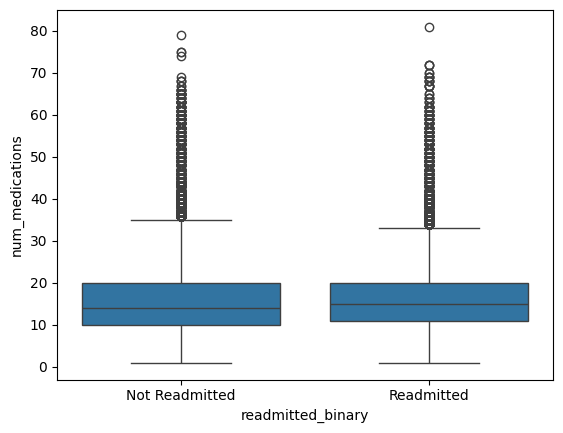

In [9]:
# Visualize

sns.boxplot(
    data=df,
    x="readmitted_binary",
    y="num_medications"
)

plt.show()

In [10]:
# Test:

readmitted_med = df[
    df["readmitted_binary"]=="Readmitted"
]["num_medications"]

not_readmitted_med = df[
    df["readmitted_binary"]=="Not Readmitted"
]["num_medications"]

stats.mannwhitneyu(
    readmitted_med,
    not_readmitted_med
)

MannwhitneyuResult(statistic=np.float64(1391734617.5), pvalue=np.float64(2.4082255330330894e-112))

# Third Test

## Previous Inpatient Visits

Do patients with previous inpatient visits experience more readmissions?

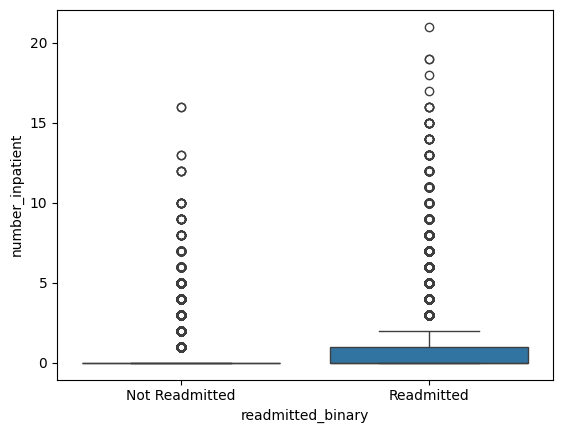

In [11]:
# Visualize

sns.boxplot(
    data=df,
    x="readmitted_binary",
    y="number_inpatient"
)

plt.show()

In [12]:
stats.mannwhitneyu(
    df[df["readmitted_binary"]=="Readmitted"]["number_inpatient"],
    df[df["readmitted_binary"]=="Not Readmitted"]["number_inpatient"]
)

MannwhitneyuResult(statistic=np.float64(1572533986.0), pvalue=np.float64(0.0))

# Categorical Analysis

Does gender related admission?

In [13]:
# Contigency Table:
table = pd.crosstab(
    df["gender"],
    df["readmitted_binary"]
)

table

readmitted_binary,Not Readmitted,Readmitted
gender,,
Female,29038,25670
Male,25823,21232
Unknown/Invalid,3,0


In [14]:
chi2, p, dof, expected = stats.chi2_contingency(table)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 35.55772261412721
P-value: 1.899934547488499e-08


### Interpretation

If p < 0.05

Gender and readmission status are associated.

Otherwise:

No significant association detected.

In [15]:
# Race vs Readmission

table = pd.crosstab(
    df["race"],
    df["readmitted_binary"]
)

stats.chi2_contingency(table)

Chi2ContingencyResult(statistic=np.float64(278.75053787116843), pvalue=np.float64(3.693156699994485e-58), dof=5, expected_freq=array([[10356.47898119,  8853.52101881],
       [  345.57537881,   295.42462119],
       [41026.42863039, 35072.57136961],
       [ 1098.18572018,   938.81427982],
       [  811.9134485 ,   694.0865515 ],
       [ 1225.41784093,  1047.58215907]]))

In [16]:
# summary:

# 1) Time in hospital
stat1, p1 = stats.mannwhitneyu(
    readmitted,
    not_readmitted,
    alternative="two-sided"
)

# 2) Number of medications
stat2, p2 = stats.mannwhitneyu(
    readmitted_med,
    not_readmitted_med,
    alternative="two-sided"
)

# 3) Prior inpatient visits
stat3, p3 = stats.mannwhitneyu(
    df[df["readmitted_binary"] == "Readmitted"]["number_inpatient"],
    df[df["readmitted_binary"] == "Not Readmitted"]["number_inpatient"],
    alternative="two-sided"
)

In [17]:
# results

results = pd.DataFrame({
    "Variable": [
        "Time in Hospital",
        "Number of Medications",
        "Prior Inpatient Visits"
    ],
    "Statistic": [stat1, stat2, stat3],
    "P-value": [p1, p2, p3]
})

results

,Variable,Statistic,P-value
0,Time in Hospital,1.376771e+09,2.116668e-84
1,Number of Medications,1.391735e+09,2.408226e-112
2,Prior Inpatient Visits,1.572534e+09,0.000000e+00


## Statistical Findings

### Significant Findings

- Variable A showed significant differences.
- Variable B showed significant differences.

### Non-Significant Findings

- Variable C showed no significant association.

### Clinical Interpretation

These findings suggest healthcare utilization and treatment intensity may be associated with readmission outcomes.